# Producto MEDI municipal y tabla puente AGEB → malla UTCI

Paso **S3** de `docs/planes/03-capas-inegi-medi.md`. Genera dos productos en
`data/derived/INEGI/2020/`:

1. `medi_mun_2020.parquet` — los mismos indicadores que la capa AGEB, pero
   por municipio (2 469), tomados de las **filas municipio** de los 32
   archivos oficiales *AGEB y manzana urbana* (Censo 2020). Esas filas son
   totales completos del municipio (urbano + rural: suman los 126 014 024
   habitantes del país), así que **no** se agregan AGEB y la censura
   prácticamente desaparece. Geometría: `00mun` del Marco Geoestadístico 2020.
2. `medi_ageb_2020_grid.parquet` — tabla sin geometría que asigna cada AGEB
   a la celda de 0.25° de la malla ERA5/UTCI que contiene su centroide, con
   los conteos necesarios para resumir un clic en el mapa sin abrir el
   GeoParquet de 74 MB.

Depende de la libreta 005 (`medi_ageb_2020.parquet`) y de la 004 (marco).

In [1]:
import io
import zipfile
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
RAW_INEGI = ROOT / "data" / "raw" / "INEGI"
AGEB_ZIPS = RAW_INEGI / "iter_2020" / "ageb_manzana"
MGN_DIR = RAW_INEGI / "mg_2020" / "conjunto_de_datos"
OUT_DIR = ROOT / "data" / "derived" / "INEGI" / "2020"
AGEB_PARQUET = OUT_DIR / "medi_ageb_2020.parquet"
OUT_MUN = OUT_DIR / "medi_mun_2020.parquet"
OUT_GRID = OUT_DIR / "medi_ageb_2020_grid.parquet"

ENTIDADES = [f"{i:02d}" for i in range(1, 33)]
EPSG_MGN, EPSG_OUT = 6372, 4326
GRID_RES = 0.25                     # malla ERA5-HEAT; centros en múltiplos de 0.25°
POB_NACIONAL_2020 = 126_014_024

assert AGEB_PARQUET.exists(), "corre primero 005_MEDI_ageb.ipynb"

## 1. Filas municipio de los 32 archivos oficiales
Municipio = `MUN != "000"` y `LOC == "0000"` (la fila entidad es `MUN == "000"`).

In [2]:
KEEP = ["ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "POBTOT", "VIVPAR_HAB", "VIVPARH_CV",
        "VPH_C_ELEC", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINRTV", "VPH_SINLTC"]


def read_rows(zip_path: Path, usecols: list[str]) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as z:
        name = next(n for n in z.namelist()
                    if n.split("/")[-1].startswith("conjunto_de_datos_ageb_urbana") and n.endswith(".csv"))
        raw = z.read(name)
    try:
        text = raw.decode("utf-8-sig")
    except UnicodeDecodeError:
        text = raw.decode("latin-1")
    return pd.read_csv(io.StringIO(text), dtype=str, usecols=usecols)


partes = []
for ee in ENTIDADES:
    df = read_rows(AGEB_ZIPS / f"ageb_mza_urbana_{ee}_cpv2020_csv.zip", KEEP + ["LOC"])
    partes.append(df[(df["MUN"] != "000") & (df["LOC"] == "0000")][KEEP])
mun = pd.concat(partes, ignore_index=True)
mun["cve_ent"] = mun["ENTIDAD"].str.zfill(2)
mun["cve_mun"] = mun["MUN"].str.zfill(3)
mun["cvegeo"] = mun["cve_ent"] + mun["cve_mun"]
assert len(mun) == 2469 and mun["cvegeo"].is_unique, len(mun)
print(len(mun), "municipios")

2469 municipios


## 2. Asteriscos, banderas e indicadores (misma regla que en 005)

In [3]:
NUM = ["POBTOT", "VIVPAR_HAB", "VIVPARH_CV", "VPH_C_ELEC", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINRTV", "VPH_SINLTC"]
for c in NUM:
    assert mun[c].str.fullmatch(r"\d+|\*").all(), c
    mun[c] = pd.to_numeric(mun[c].replace("*", pd.NA)).astype("Int64")
print("asteriscos por columna:", {c: int(mun[c].isna().sum()) for c in NUM})
assert int(mun["POBTOT"].sum()) == POB_NACIONAL_2020, int(mun["POBTOT"].sum())

den = mun["VIVPARH_CV"]
ok_den = den.notna() & (den > 0)


def flag(num_col: str) -> pd.Series:
    f = pd.Series("ok", index=mun.index)
    f[~ok_den] = "sin_viviendas"
    f[ok_den & mun[num_col].isna()] = "censurado"
    return f


mun["vph_sin_refri"] = (den - mun["VPH_REFRI"]).astype("Int64")
mun["p_sin_elec"] = (mun["VPH_S_ELEC"] / den * 100).where(ok_den).astype("float64")
mun["p_sin_refri"] = (mun["vph_sin_refri"] / den * 100).where(ok_den).astype("float64")
mun["flag_elec"] = flag("VPH_S_ELEC")
mun["flag_refri"] = flag("VPH_REFRI")
mun["p_sin_telef"] = (mun["VPH_SINLTC"] / den * 100).where(ok_den).astype("float64")
mun["p_sin_rtv"] = (mun["VPH_SINRTV"] / den * 100).where(ok_den).astype("float64")
mun["flag_telef"] = flag("VPH_SINLTC")
mun["flag_rtv"] = flag("VPH_SINRTV")
resto = (den - mun["VPH_C_ELEC"]).clip(lower=0)
cota = np.minimum(resto.fillna(2).astype("float64"), 2.0)
mun["p_sin_elec_sup"] = np.where(mun["flag_elec"] == "censurado", cota / den.astype("float64") * 100, mun["p_sin_elec"])
for c in ["p_sin_elec", "p_sin_refri", "p_sin_elec_sup", "p_sin_telef", "p_sin_rtv"]:
    s = mun[c].dropna()
    assert ((s >= 0) & (s <= 100)).all(), c
for f in ["flag_elec", "flag_refri", "flag_telef", "flag_rtv"]:
    print(f, mun[f].value_counts().to_dict())
print(mun[["p_sin_elec", "p_sin_refri", "p_sin_telef", "p_sin_rtv"]].describe().round(2).T)

asteriscos por columna: {'POBTOT': 0, 'VIVPAR_HAB': 0, 'VIVPARH_CV': 0, 'VPH_C_ELEC': 0, 'VPH_S_ELEC': 103, 'VPH_REFRI': 0, 'VPH_SINRTV': 3, 'VPH_SINLTC': 0}
flag_elec {'ok': 2366, 'censurado': 103}
flag_refri {'ok': 2469}
flag_telef {'ok': 2469}
flag_rtv {'ok': 2466, 'censurado': 3}
              count   mean    std   min   25%    50%    75%    max
p_sin_elec   2366.0   1.90   2.87  0.00  0.58   1.23   2.25  50.09
p_sin_refri  2469.0  25.95  20.75  0.88  9.67  19.54  36.12  95.92
p_sin_telef  2469.0  21.56  17.27  0.28  8.96  16.11  28.34  92.06
p_sin_rtv    2466.0  11.73  10.85  0.20  4.19   8.10  15.47  77.14


## 3. Número de AGEB urbanas por municipio (contexto) y unión con `00mun`

In [4]:
ageb = pd.read_parquet(AGEB_PARQUET, columns=["cvegeo", "cve_ent", "cve_mun", "pobtot", "vivparh_cv",
                                                "vph_c_elec", "vph_s_elec", "vph_refri", "vph_sin_refri",
                                                "vph_sinltc", "vph_sinrtv",
                                                "flag_elec", "flag_refri", "flag_telef", "flag_rtv",
                                                "cent_lon", "cent_lat"])
n_ageb = ageb.groupby(ageb["cve_ent"] + ageb["cve_mun"]).size().rename("n_ageb")
mun = mun.merge(n_ageb, left_on="cvegeo", right_index=True, how="left")
mun["n_ageb"] = mun["n_ageb"].fillna(0).astype("Int64")
mun["pob_ageb_urb"] = mun["cvegeo"].map(ageb.groupby(ageb["cve_ent"] + ageb["cve_mun"])["pobtot"].sum()).fillna(0).astype("Int64")
print("municipios sin AGEB urbana en el ITER:", int((mun["n_ageb"] == 0).sum()))

mgn_mun = gpd.read_file(MGN_DIR / "00mun.shp").set_crs(EPSG_MGN, allow_override=True)[["CVEGEO", "geometry"]]
g = mun.merge(mgn_mun, left_on="cvegeo", right_on="CVEGEO", how="left").drop(columns="CVEGEO")
assert g["geometry"].notna().all(), "municipios sin polígono"
gdf = gpd.GeoDataFrame(g, geometry="geometry", crs=EPSG_MGN)
cent = gdf.geometry.centroid.to_crs(EPSG_OUT)
gdf["cent_lon"], gdf["cent_lat"] = cent.x, cent.y
gdf = gdf.to_crs(EPSG_OUT)

municipios sin AGEB urbana en el ITER: 0


## 4. Escritura del municipal

In [5]:
gdf = gdf.rename(columns={
    "NOM_ENT": "nom_ent", "NOM_MUN": "nom_mun",
    "POBTOT": "pobtot", "VIVPAR_HAB": "vivpar_hab", "VIVPARH_CV": "vivparh_cv",
    "VPH_C_ELEC": "vph_c_elec", "VPH_S_ELEC": "vph_s_elec", "VPH_REFRI": "vph_refri",
    "VPH_SINRTV": "vph_sinrtv", "VPH_SINLTC": "vph_sinltc",
})
COLS = ["cvegeo", "cve_ent", "cve_mun", "nom_ent", "nom_mun",
        "pobtot", "vivpar_hab", "vivparh_cv", "vph_c_elec", "vph_s_elec", "vph_refri", "vph_sin_refri",
        "vph_sinrtv", "vph_sinltc", "p_sin_elec", "p_sin_elec_sup", "p_sin_refri", "p_sin_telef", "p_sin_rtv",
        "flag_elec", "flag_refri", "flag_telef", "flag_rtv",
        "n_ageb", "pob_ageb_urb", "cent_lon", "cent_lat", "geometry"]
gdf = gdf[COLS].sort_values("cvegeo").reset_index(drop=True)
gdf.to_parquet(OUT_MUN, index=False, write_covering_bbox=True)
print("escrito", OUT_MUN, f"{OUT_MUN.stat().st_size/1e6:.1f} MB", gdf.shape)

escrito /Users/gbv/atlas/data/derived/INEGI/2020/medi_mun_2020.parquet 57.5 MB (2469, 28)


## 5. Tabla puente AGEB → celda UTCI (0.25°)
La malla ERA5-HEAT tiene los centros de celda en múltiplos de 0.25°
(lat 14.0 … 33.5, lon −118.5 … −86.0). Cada AGEB se asigna a la celda cuyo
centro está más cerca de su centroide, es decir, la que la contiene. Es
independiente del año UTCI: sólo cambia el recorte de la malla, no su lattice.

In [6]:
def to_cell(x: pd.Series) -> pd.Series:
    return (np.round(x / GRID_RES) * GRID_RES).round(2)


grid = pd.DataFrame({
    "cvegeo": ageb["cvegeo"],
    "lat_c": to_cell(ageb["cent_lat"]),
    "lon_c": to_cell(ageb["cent_lon"]),
    "pobtot": ageb["pobtot"], "vivparh_cv": ageb["vivparh_cv"],
    "vph_s_elec": ageb["vph_s_elec"], "vph_c_elec": ageb["vph_c_elec"],
    "vph_refri": ageb["vph_refri"], "vph_sin_refri": ageb["vph_sin_refri"],
    "vph_sinltc": ageb["vph_sinltc"], "vph_sinrtv": ageb["vph_sinrtv"],
    "flag_elec": ageb["flag_elec"], "flag_refri": ageb["flag_refri"],
    "flag_telef": ageb["flag_telef"], "flag_rtv": ageb["flag_rtv"],
})
grid.to_parquet(OUT_GRID, index=False)
print("escrito", OUT_GRID, f"{OUT_GRID.stat().st_size/1e6:.2f} MB", grid.shape)

# Verificación contra la malla real del STAC (último año disponible)
from atlas import stac

lv = stac.open_levels(stac.available_years()[-1])
lat, lon = lv["lat"].values, lv["lon"].values
dentro = grid["lat_c"].between(lat.min(), lat.max()) & grid["lon_c"].between(lon.min(), lon.max())
print(f"AGEB dentro de la malla {stac.available_years()[-1]}: {int(dentro.sum())} de {len(grid)}")
assert dentro.all(), "hay AGEB fuera del bbox de la malla UTCI"
assert grid["lat_c"].isin(np.round(lat, 2)).all() and grid["lon_c"].isin(np.round(lon, 2)).all()
celdas = grid.groupby(["lat_c", "lon_c"]).size()
print(f"celdas con AGEB: {len(celdas)} de {len(lat) * len(lon)}; máx AGEB por celda: {int(celdas.max())}; "
      f"mediana: {celdas.median():.0f}")

escrito /Users/gbv/atlas/data/derived/INEGI/2020/medi_ageb_2020_grid.parquet 1.25 MB (64313, 15)


AGEB dentro de la malla 2023: 64313 de 64313
celdas con AGEB: 1381 de 10349; máx AGEB por celda: 1398; mediana: 19


## 6. Verificación: ida y vuelta y ejemplo de resumen por celda

In [7]:
chk = gpd.read_parquet(OUT_MUN)
assert chk.crs.to_epsg() == EPSG_OUT and len(chk) == 2469 and chk["cvegeo"].is_unique
assert int(chk["pobtot"].sum()) == POB_NACIONAL_2020
print("municipal reabre OK:", chk.shape, "| p_sin_elec nulo:", int(chk["p_sin_elec"].isna().sum()),
      "| p_sin_refri nulo:", int(chk["p_sin_refri"].isna().sum()))


def resumen_celda(lat_c: float, lon_c: float) -> dict:
    """Lo que mostrará el pie de página al hacer clic: sumas sobre AGEB no censuradas."""
    sel = grid[(grid["lat_c"] == lat_c) & (grid["lon_c"] == lon_c)]
    e = sel[sel["flag_elec"] == "ok"]
    r = sel[sel["flag_refri"] == "ok"]
    return {
        "n_ageb": len(sel), "pobtot": int(sel["pobtot"].sum()),
        "p_sin_elec": round(float(e["vph_s_elec"].sum() / e["vivparh_cv"].sum() * 100), 2) if len(e) else None,
        "p_sin_refri": round(float(r["vph_sin_refri"].sum() / r["vivparh_cv"].sum() * 100), 2) if len(r) else None,
    }


print("Mérida centro (21.0, -89.5):", resumen_celda(21.0, -89.5))
print("CDMX centro (19.5, -99.25):", resumen_celda(19.5, -99.25))
print("celda sin AGEB (30.0, -110.0):", resumen_celda(30.0, -110.0))

municipal reabre OK: (2469, 28) | p_sin_elec nulo: 103 | p_sin_refri nulo: 0
Mérida centro (21.0, -89.5): {'n_ageb': 342, 'pobtot': 588469, 'p_sin_elec': 0.3, 'p_sin_refri': 5.15}
CDMX centro (19.5, -99.25): {'n_ageb': 1391, 'pobtot': 5180907, 'p_sin_elec': 0.02, 'p_sin_refri': 5.4}
celda sin AGEB (30.0, -110.0): {'n_ageb': 0, 'pobtot': 0, 'p_sin_elec': None, 'p_sin_refri': None}


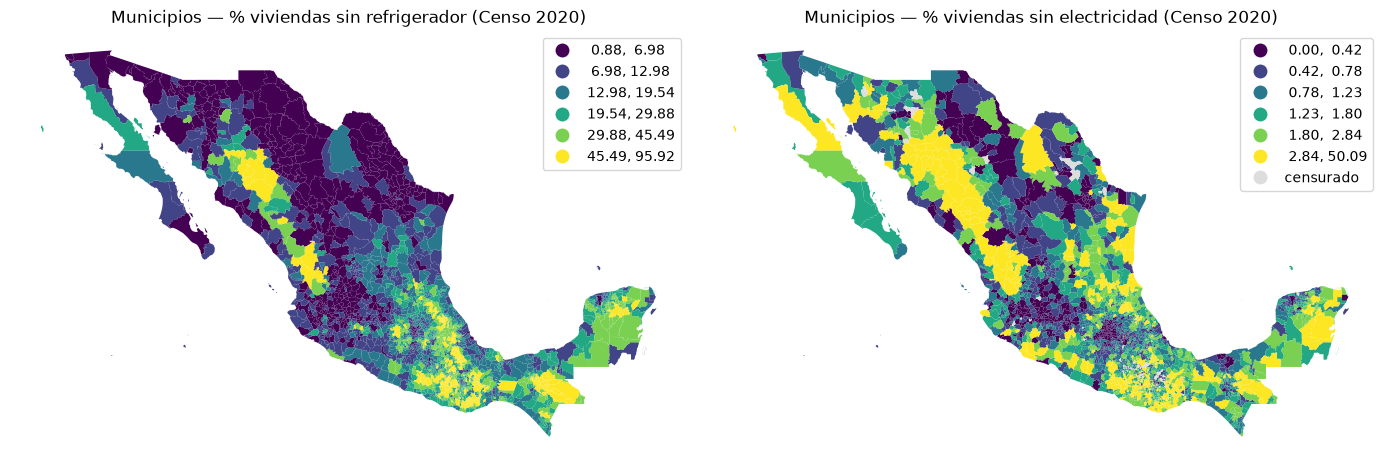

In [8]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, col, titulo in [(axs[0], "p_sin_refri", "% viviendas sin refrigerador"),
                        (axs[1], "p_sin_elec", "% viviendas sin electricidad")]:
    chk.plot(column=col, ax=ax, cmap="viridis", legend=True, scheme="quantiles", k=6,
             edgecolor="none", missing_kwds={"color": "#dddddd", "label": "censurado"})
    ax.set_title(f"Municipios — {titulo} (Censo 2020)")
    ax.set_axis_off()
plt.tight_layout()